# Modelos de Regresión 

In [18]:
import sys
!{sys.executable} -m pip install statsmodels

In [19]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)


import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor


In [20]:
df = pd.read_csv("train.csv")
X_train = pd.read_csv("X_train.csv")
y_train = pd.read_csv("y_train.csv")
X_test = pd.read_csv("X_test.csv")
y_test = pd.read_csv("y_test.csv")

### Modelo Univariado

In [21]:
X_uni = X_train[["OverallQual"]]

model_uni = sm.OLS(y_train, sm.add_constant(X_uni)).fit()

print(model_uni.summary())


                            OLS Regression Results                            
Dep. Variable:              SalePrice   R-squared:                       0.617
Model:                            OLS   Adj. R-squared:                  0.617
Method:                 Least Squares   F-statistic:                     1879.
Date:                Sun, 15 Mar 2026   Prob (F-statistic):          2.60e-245
Time:                        10:55:41   Log-Likelihood:                -14242.
No. Observations:                1168   AIC:                         2.849e+04
Df Residuals:                    1166   BIC:                         2.850e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const       -9.023e+04   6421.492    -14.052      

In [22]:
# Eliminar filas con NaN
mask = X_uni["OverallQual"].notna()
X_uni = X_uni[mask]
y_train_uni = y_train[mask]  # usa y_train_uni en el modelo

model_uni = sm.OLS(y_train_uni, sm.add_constant(X_uni)).fit()
y_pred_uni = model_uni.predict(sm.add_constant(X_uni))

residuos = y_train_uni - y_pred_uni

In [23]:
X_uni_const = sm.add_constant(X_uni, has_constant='add')
print(X_uni_const.shape)  # debe ser (1168, 2)

y_pred_uni = model_uni.predict(X_uni_const)
print(y_pred_uni.shape)  # debe ser (1168,)

(1168, 2)
(1168,)


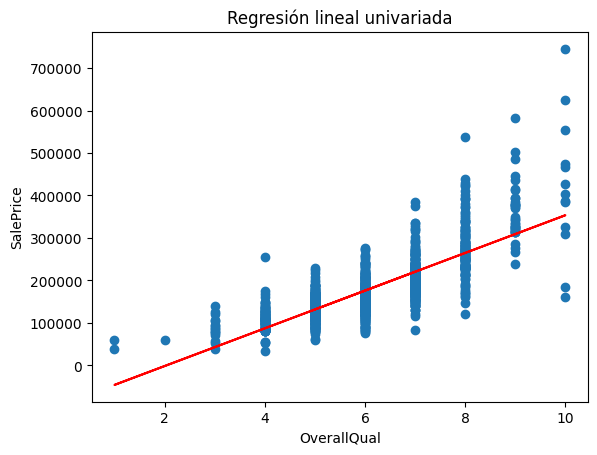

In [24]:
#Predicciones
y_pred_uni = model_uni.predict(sm.add_constant(X_uni))

plt.scatter(X_uni, y_train)
plt.plot(X_uni, y_pred_uni, color="red")
plt.xlabel("OverallQual")
plt.ylabel("SalePrice")
plt.title("Regresión lineal univariada")
plt.show()


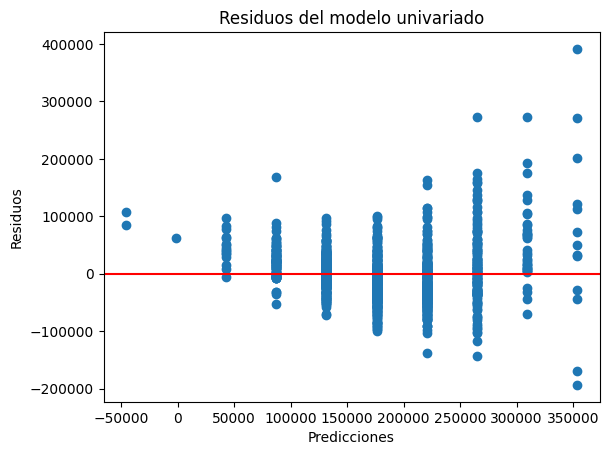

In [25]:
#Análisis de residuos
residuos = y_train.values.flatten() - y_pred_uni

plt.scatter(y_pred_uni, residuos)
plt.axhline(0, color="red")
plt.xlabel("Predicciones")
plt.ylabel("Residuos")
plt.title("Residuos del modelo univariado")
plt.show()

### Modelo Multivariado

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

X = df.select_dtypes(include=np.number).drop("SalePrice", axis=1)
y = df["SalePrice"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

imputer = SimpleImputer(strategy="median")

X_train = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test = pd.DataFrame(
    imputer.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

In [27]:
modelo1 = LinearRegression()
modelo1.fit(X_train, y_train)
y_pred_modelo1 = modelo1.predict(X_test)

In [28]:
print(modelo1.get_params()) # los hiperparámetros del modelo
print(y_pred_modelo1) #los valores devueltos por el modelo

{'copy_X': True, 'fit_intercept': True, 'n_jobs': None, 'positive': False, 'tol': 1e-06}
[153737.1109465  309259.1242082  112941.47492336 180545.09314931
 294935.37195546  50949.5225347  233719.76461167 147987.78380296
  48583.78744827 149799.35335429 153100.81355441 113805.54037327
  75236.18901691 212636.47913574 187679.14474404 141182.57381482
 213179.9845719  137033.01655182 114741.61196028 235277.69989839
 182213.51325558 210965.72703788 190407.37847838 129927.47452541
 211536.81937502 151170.43468486 198313.05236926  77790.49070999
 178939.40245883 182658.30168746 118373.45893454 271933.91760506
 225337.57139235  88856.99709705 266062.898738   159821.45068506
 148348.01584186 217731.07341957 304063.48778385  88080.05300017
 136909.60945894 249654.76034804 105422.96425859 275242.74273576
 128497.16227552 126409.29199397 103155.14347608 131549.17358334
 360526.34695517 128119.98431393 107014.25022759 214715.6987527
  89172.66179568 329468.51350891 162497.53115866 248709.85786956
 2

In [29]:
sm.OLS(y_train,X_train).fit().summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:              SalePrice   R-squared (uncentered):                   0.970
Model:                            OLS   Adj. R-squared (uncentered):              0.970
Method:                 Least Squares   F-statistic:                              1063.
Date:                Sun, 15 Mar 2026   Prob (F-statistic):                        0.00
Time:                        10:55:57   Log-Likelihood:                         -13841.
No. Observations:                1168   AIC:                                  2.775e+04
Df Residuals:                    1133   BIC:                                  2.793e+04
Df Model:                          35                                                  
Covariance Type:            nonrobust                                                  
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Id               -2.2221      2.406     -0.923      0.356      -6.944       2.499
MSSubClass     -202.4319     30.676     -6.599      0.000    -262.620    -142.244
LotFrontage    -132.8528     55.828     -2.380      0.017    -242.391     -23.315
LotArea           0.4536      0.105      4.316      0.000       0.247       0.660
OverallQual    1.793e+04   1314.722     13.636      0.000    1.53e+04    2.05e+04
OverallCond    4202.2521   1138.478      3.691      0.000    1968.489    6436.015
YearBuilt       267.8852     73.847      3.628      0.000     122.992     412.778
YearRemodAdd    167.5834     75.797      2.211      0.027      18.865     316.302
MasVnrArea       24.7552      6.922      3.576      0.000      11.174      38.336
BsmtFinSF1        9.1085      2.807      3.245      0.001       3.602      14.615
BsmtFinSF2       -2.8432      5.134     -0.554      0.580     -12.917       7.231
BsmtUnfSF        -0.5561      2.720     -0.204      0.838      -5.893       4.781
TotalBsmtSF       5.7092      3.818      1.495      0.135      -1.781      13.200
1stFlrSF         13.4030      6.975      1.922      0.055      -0.282      27.088
2ndFlrSF         14.4287      6.374      2.264      0.024       1.922      26.935
LowQualFinSF      3.8414     16.799      0.229      0.819     -29.120      36.803
GrLivArea        31.6731      6.405      4.945      0.000      19.107      44.240
BsmtFullBath   1.133e+04   2866.433      3.951      0.000    5702.335     1.7e+04
BsmtHalfBath  -1167.7428   4600.036     -0.254      0.800   -1.02e+04    7857.803
FullBath       2905.9865   3155.598      0.921      0.357   -3285.487    9097.460
HalfBath      -2313.6331   2926.129     -0.791      0.429   -8054.873    3427.607
BedroomAbvGr  -8630.5217   1928.050     -4.476      0.000   -1.24e+04   -4847.573
KitchenAbvGr  -9507.3000   5764.451     -1.649      0.099   -2.08e+04    1802.899
TotRmsAbvGrd   5110.2209   1391.089      3.674      0.000    2380.820    7839.622
Fireplaces     4778.9358   1963.883      2.433      0.015     925.680    8632.191
GarageYrBlt     136.6100     75.272      1.815      0.070     -11.078     284.298
GarageCars     1.241e+04   3217.737      3.856      0.000    6092.804    1.87e+04
GarageArea       -4.1048     11.219     -0.366      0.715     -26.117      17.907
WoodDeckSF       21.4321      8.647      2.478      0.013       4.465      38.399
OpenPorchSF      -5.6633     16.092     -0.352      0.725     -37.238      25.911
EnclosedPorch     9.2065     18.484      0.498      0.619     -27.061      45.474
3SsnPorch        39.4038     32.481      1.213      0.225     -24.326     103.134
ScreenPorch      63.5681     19.176      3.315      0.001      25.943     101.193
PoolArea        -18.6291     25.

# METRICAS MODELO

In [30]:
# calculate aic for regression 
def calculate_aic(n, mse, num_params):
 aic = n * np.log(mse) + 2 * num_params
 return aic
# calculate bic for regression
def calculate_bic(n, mse, num_params):
 bic = n * np.log(mse) + num_params * np.log(n)
 return bic

In [31]:
from sklearn.metrics import mean_squared_error,r2_score
import sklearn.metrics as metrics

# Regression metrics
explained_variance_modelo1=metrics.explained_variance_score(y_test, y_pred_modelo1)
mean_absolute_error_modelo1=metrics.mean_absolute_error(y_test, y_pred_modelo1) 
mse_modelo1=metrics.mean_squared_error(y_test, y_pred_modelo1) 
mean_squared_log_error_modelo1=metrics.mean_squared_log_error(y_test, y_pred_modelo1)
median_absolute_error_modelo1=metrics.median_absolute_error(y_test, y_pred_modelo1)
r2_modelo1=metrics.r2_score(y_test, y_pred_modelo1)
k = modelo1.coef_.size
n = X_train.shape[0]
aic_modelo1 = calculate_aic(n,mse_modelo1,k)
bic_modelo1 = calculate_bic(n,mse_modelo1,k)

print('explained_variance: ', round(explained_variance_modelo1,4))   
print('mean_squared_log_error: ', round(mean_squared_log_error_modelo1,4))
print('r2: ', round(r2_modelo1,4))
print('MAE: ', round(mean_absolute_error_modelo1,4))
print('MSE: ', round(mse_modelo1,4))
print('RMSE: ', round(np.sqrt(mse_modelo1),4))
print('AIC: ',round(aic_modelo1,4))
print('BIC: ',round(bic_modelo1,4))

explained_variance:  0.8247
mean_squared_log_error:  0.0358
r2:  0.8227
MAE:  23001.7311
MSE:  1360318345.5164
RMSE:  36882.4938
AIC:  24638.19
BIC:  24825.5228


- Rˆ2: El modelo explica el 82.27% de la variabilidad del consumo en ciudad
- explained_Variance: mide qué proporción de la variación del target está explicando el modelo. [Cuando los errores tienen media cercana a cero (como en regresión lineal) explained variance ≈ R2]
- Mean_squared_log_Error: Este mide el error después de aplicar logaritmo. Se usa cuando: hay valores muy grandes, o queremos penalizar más los errores relativos que absolutos
- MAE: mean absolute error, Promedio del error absoluto. En promedio, el modelo se equivoca por 23001.73.
- MSE: Mean Square Error. Penaliza más los errores grandes.
- RMSE: La raíz cuadrada del anterior. Como RMSE > MAE, significa que hay algunos errores grandes que están influyendo. (si fueran iguales, significaría que los errores son más o menos muy uniformes)

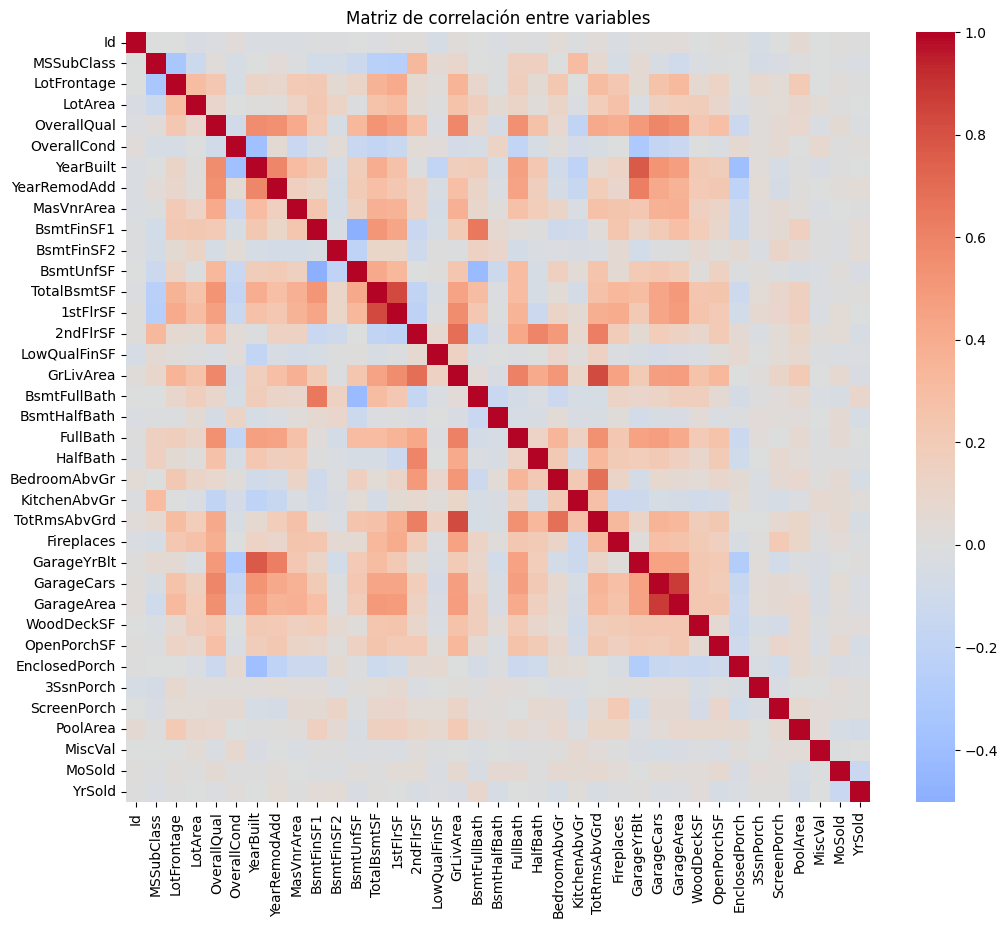

In [32]:
corr_matrix = X_train.corr()

plt.figure(figsize=(12,10))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Matriz de correlación entre variables")
plt.show()

In [33]:
corr_matrix = X_train.corr()

high_corr = corr_matrix[(corr_matrix > 0.8) & (corr_matrix < 1)]

high_corr.dropna(how="all").dropna(axis=1, how="all")

,TotalBsmtSF,1stFlrSF,GrLivArea,TotRmsAbvGrd,GarageCars,GarageArea
TotalBsmtSF,NaN,0.827382,NaN,NaN,NaN,NaN
1stFlrSF,0.827382,NaN,NaN,NaN,NaN,NaN
GrLivArea,NaN,NaN,NaN,0.820718,NaN,NaN
TotRmsAbvGrd,NaN,NaN,0.820718,NaN,NaN,NaN
GarageCars,NaN,NaN,NaN,NaN,NaN,0.88255
GarageArea,NaN,NaN,NaN,NaN,0.88255,NaN


In [34]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_validate

linear_model = make_pipeline(
    StandardScaler(),
    LinearRegression()
)


cv_results_linear = cross_validate(
    linear_model,
    X_train,
    y_train,
    cv=cv,
    scoring="neg_mean_squared_error",
    return_train_score=True,
    n_jobs=2
)

NameError: name 'cv' is not defined

Train MSE: 1123172683.3600752 +- 99112284.2437424
Test MSE: 1472683697.8621678 +- 541186100.3295827


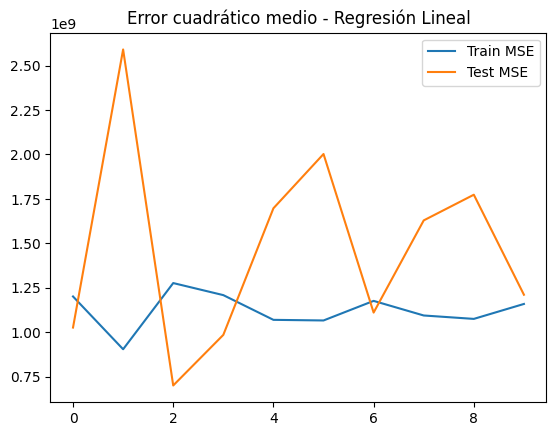

In [142]:
train_error_linear = -cv_results_linear["train_score"]
test_error_linear = -cv_results_linear["test_score"]

print("Train MSE:", train_error_linear.mean(), "+-", train_error_linear.std())
print("Test MSE:", test_error_linear.mean(), "+-", test_error_linear.std())

plt.plot(train_error_linear, label="Train MSE")
plt.plot(test_error_linear, label="Test MSE")

plt.legend()
plt.title("Error cuadrático medio - Regresión Lineal")

plt.show()

In [145]:
train_mean = train_error_linear.mean()
test_mean = test_error_linear.mean()

gap = test_mean - train_mean

gap_percent = (gap / train_mean) * 100

print("Train MSE promedio:", train_mean)
print("Test MSE promedio:", test_mean)
print("Gap:", gap)
print("Gap porcentual:", gap_percent, "%")

Train MSE promedio: 1123172683.3600752
Test MSE promedio: 1472683697.8621678
Gap: 349511014.5020926
Gap porcentual: 31.11819043323757 %


# ANALISIS DE RESIDUOS

Text(0, 0.5, 'Residuales')

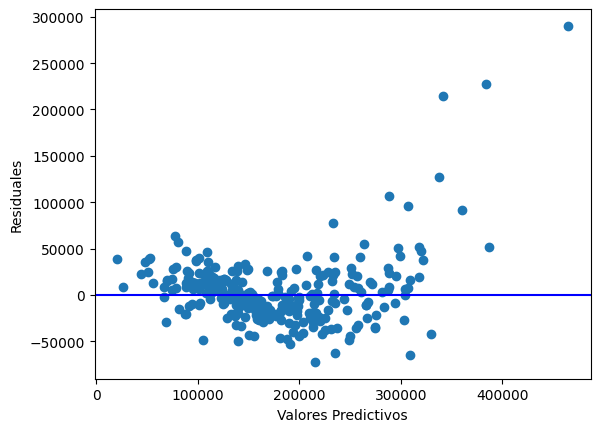

In [119]:
resid_modelo1=y_test-y_pred_modelo1
plt.scatter(y_pred_modelo1,resid_modelo1)
plt.axhline(0,color='blue')
plt.xlabel('Valores Predictivos')
plt.ylabel('Residuales')

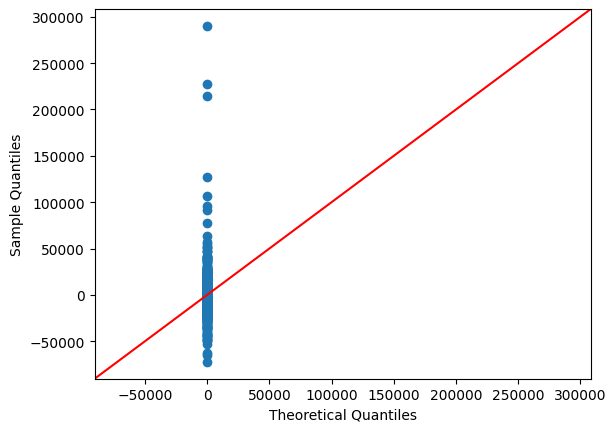

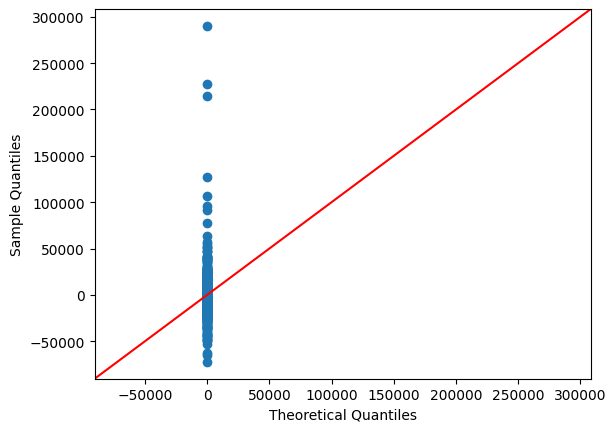

In [120]:
sm.qqplot(resid_modelo1,line='45')

In [121]:
k,p=sm.stats.diagnostic.lilliefors(resid_modelo1)
print("p =",p)

p = 0.0009999999999998899


In [122]:
x_pred_modelo1 = modelo1.predict(X_train)
mse_modelo1_train=metrics.mean_squared_error(y_train, x_pred_modelo1) 

print("MSE_train: ",round(mse_modelo1_train,4))
print('MSE_test: ', round(mse_modelo1,4))

MSE_train:  1149564637.0987
MSE_test:  1360318345.5165


# LASSO

In [129]:
from sklearn.linear_model import LassoCV
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import ShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_validate

lasso = make_pipeline(StandardScaler(), LassoCV(alphas = np.arange(0,1,0.02), cv=cv, n_jobs = 2))

cv_results_lasso = cross_validate(lasso, X_train, y_train,
                            cv=cv, scoring="neg_mean_squared_error",
                            return_train_score=True,
                            return_estimator=True, n_jobs=2)

train_error = -cv_results_lasso["train_score"]
print(f"Error medio cuadrado de la regresión con datos de entrenamiento:\n"
      f"{train_error.mean():.3f} ± {train_error.std():.3f}")

test_error_lasso = -cv_results_lasso["test_score"]
print(f"Error medio cuadrado de la regresion con los datos de prueba:\n"
      f"{test_error_lasso.mean():.3f} ± {test_error_lasso.std():.3f}")
alphas = []
for est in cv_results_lasso["estimator"]:
    alphas.append(est[1].alpha_)
print
print(alphas)
-cv_results_lasso["test_score"]

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.924e+09, tolerance: 4.112e+08
  model = cd_fast.enet_coordinate_descent_gram(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.923e+09, tolerance: 4.112e+08
  model = cd_fast.enet_coordinate_descent_gram(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:701: UserWarning: Coordinate descent without L1 regularization may lead to unexpected re

Error medio cuadrado de la regresión con datos de entrenamiento:
1123172734.497 ± 99112288.450
Error medio cuadrado de la regresion con los datos de prueba:
1472585771.395 ± 541152553.293
[np.float64(0.98), np.float64(0.9), np.float64(0.98), np.float64(0.98), np.float64(0.98), np.float64(0.98), np.float64(0.98), np.float64(0.98), np.float64(0.98), np.float64(0.98)]


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.058e+09, tolerance: 4.446e+08
  model = cd_fast.enet_coordinate_descent_gram(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:701: UserWarning: Coordinate descent without L1 regularization may lead to unexpected results and is discouraged. Set l1_ratio > 0 to add L1 regularization.
  model = cd_fast.enet_coordinate_descent_gram(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider inc

array([1.02630680e+09, 2.59050699e+09, 7.00470195e+08, 9.85034269e+08,
       1.69717081e+09, 2.00243339e+09, 1.11055161e+09, 1.62904344e+09,
       1.77340613e+09, 1.21093410e+09])

In [130]:
alphas = []
for est in cv_results_lasso["estimator"]:
    alphas.append(est[1].alpha_)

print(alphas)

[np.float64(0.98), np.float64(0.9), np.float64(0.98), np.float64(0.98), np.float64(0.98), np.float64(0.98), np.float64(0.98), np.float64(0.98), np.float64(0.98), np.float64(0.98)]


In [133]:
np.mean(alphas)

np.float64(0.9720000000000001)

In [134]:
modelo4 = Lasso(alpha=0.972)
modelo4.fit(X_train, y_train)

# Predict the target values on the testing set
y_pred_modelo4 = modelo4.predict(X_test)

In [135]:
# Regression metrics
explained_variance_modelo4=metrics.explained_variance_score(y_test, y_pred_modelo4)
mean_absolute_error_modelo4=metrics.mean_absolute_error(y_test, y_pred_modelo4) 
mse_modelo4=metrics.mean_squared_error(y_test, y_pred_modelo4) 
mean_squared_log_error_modelo4=metrics.mean_squared_log_error(y_test, y_pred_modelo4)
median_absolute_error_modelo4=metrics.median_absolute_error(y_test, y_pred_modelo4)
r2_modelo4=metrics.r2_score(y_test, y_pred_modelo4)
k = modelo4.coef_.size
n = X_train.shape[0]
aic_modelo4 = calculate_aic(n,mse_modelo4,k)
bic_modelo4 = calculate_bic(n,mse_modelo4,k)

print('explained_variance: ', round(explained_variance_modelo4,4))   
print('mean_squared_log_error: ', round(mean_squared_log_error_modelo4,4))
print('r2: ', round(r2_modelo4,4))
print('MAE: ', round(mean_absolute_error_modelo4,4))
print('MSE: ', round(mse_modelo4,4))
print('RMSE: ', round(np.sqrt(mse_modelo4),4))
print('AIC: ',round(aic_modelo4,4))
print('BIC: ',round(bic_modelo4,4))

explained_variance:  0.8247
mean_squared_log_error:  0.0358
r2:  0.8227
MAE:  23001.9383
MSE:  1360294654.9321
RMSE:  36882.1726
AIC:  24638.1697
BIC:  24825.5024


Train MSE promedio: 1123172734.4967206
Test MSE promedio: 1472585771.3947473


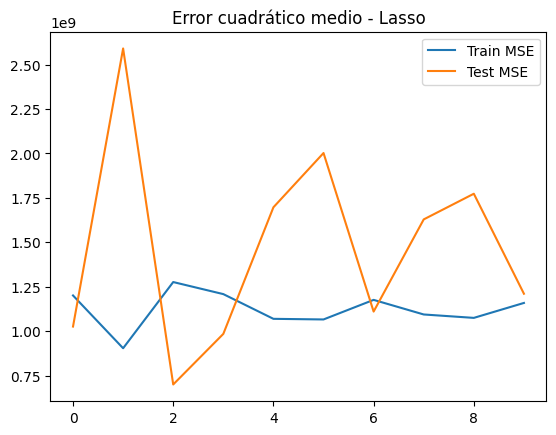

In [140]:
print("Train MSE promedio:", train_error.mean())
print("Test MSE promedio:", test_error_lasso.mean())

plt.plot(train_error, label="Train MSE")
plt.plot(test_error_lasso, label="Test MSE")

plt.legend()
plt.title("Error cuadrático medio - Lasso")

plt.show()

# ANÁLISIS DE RESIDUOS LASSO

In [146]:
lasso.fit(X_train, y_train)

y_pred_lasso = lasso.predict(X_test)

residuos_lasso = y_test - y_pred_lasso

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.036e+09, tolerance: 5.415e+08
  model = cd_fast.enet_coordinate_descent_gram(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.693e+09, tolerance: 5.453e+08
  model = cd_fast.enet_coordinate_descent_gram(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the numb

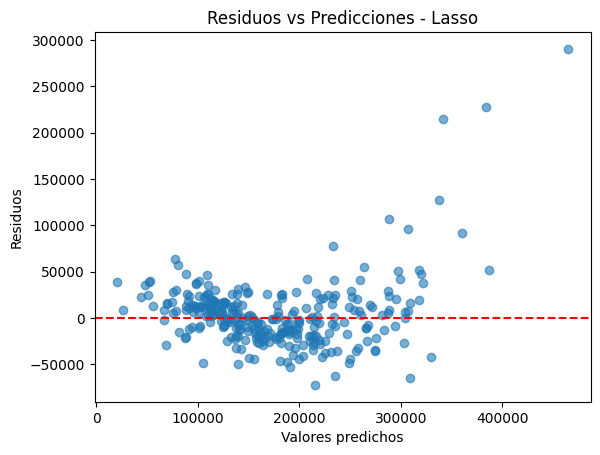

In [147]:
import matplotlib.pyplot as plt

plt.scatter(y_pred_lasso, residuos_lasso, alpha=0.6)

plt.axhline(0, color="red", linestyle="--")

plt.xlabel("Valores predichos")
plt.ylabel("Residuos")

plt.title("Residuos vs Predicciones - Lasso")

plt.show()

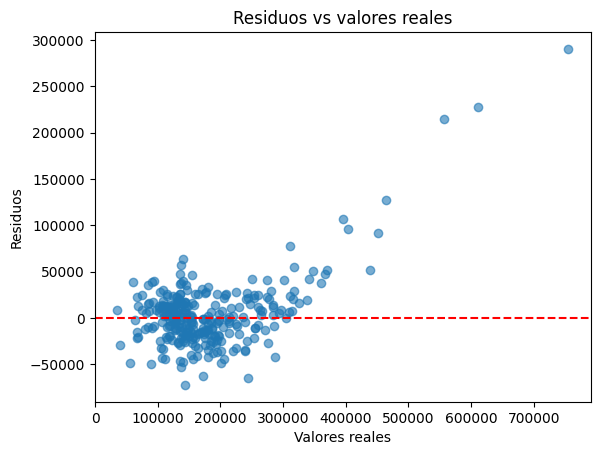

In [153]:
plt.scatter(y_test, residuos_lasso, alpha=0.6)

plt.axhline(0, color="red", linestyle="--")

plt.xlabel("Valores reales")
plt.ylabel("Residuos")

plt.title("Residuos vs valores reales")

plt.show()

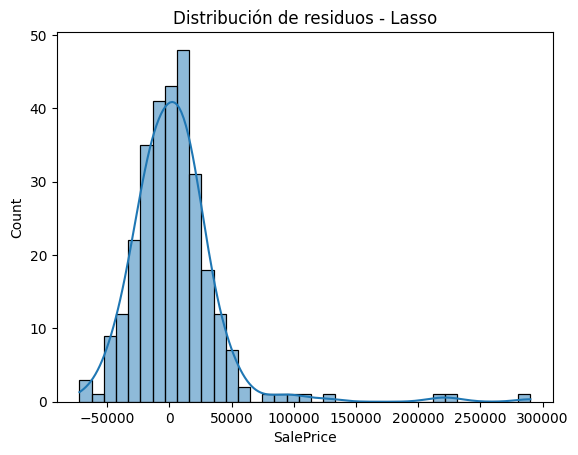

In [148]:
import seaborn as sns

sns.histplot(residuos_lasso, kde=True)

plt.title("Distribución de residuos - Lasso")

plt.show()

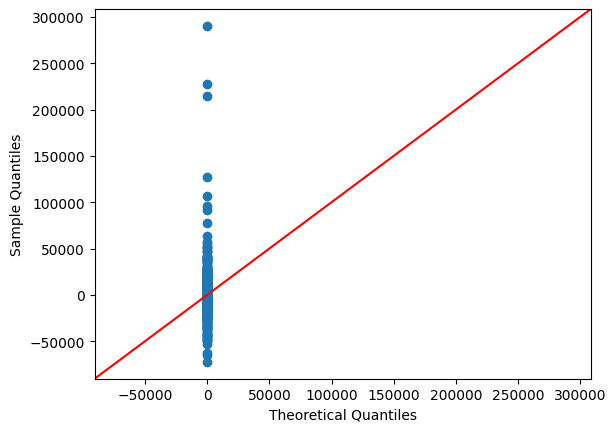

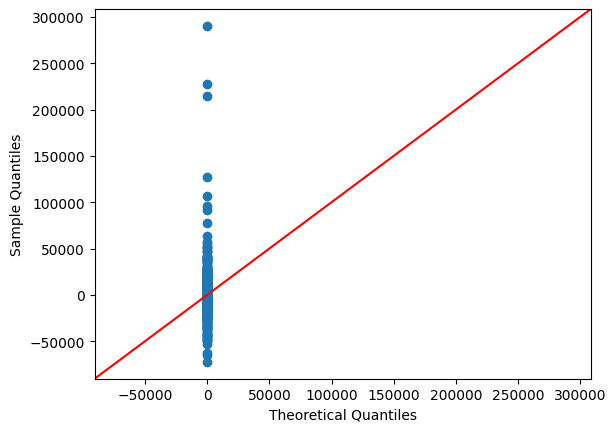

In [151]:
sm.qqplot(residuos_lasso,line='45')

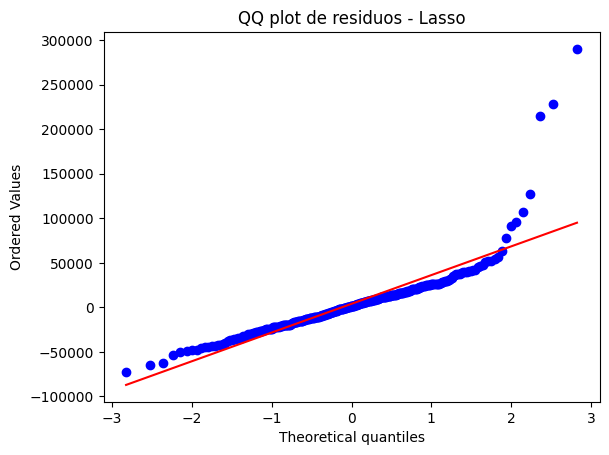

In [149]:
import scipy.stats as stats

stats.probplot(residuos_lasso, dist="norm", plot=plt)

plt.title("QQ plot de residuos - Lasso")

plt.show()